In [1]:
!pip install -q yfinance duckdb pandas pyarrow requests lxml
print('Dependencies installed.')

Dependencies installed.


In [2]:
import yfinance as yf
import duckdb
import pandas as pd
import numpy as np
import requests
import time
import os
import xml.etree.ElementTree as ET
from datetime import datetime
from pathlib import Path

DB_PATH     = 'stock_data.db'
PARQUET_DIR = Path('parquet_exports')
PARQUET_DIR.mkdir(exist_ok=True)

REQUEST_DELAY = 0.4   # seconds between ticker requests (be polite)
BATCH_SIZE    = 50    # flush to DB every N tickers
MAX_TICKERS   = 500   # set lower (e.g. 20) for a quick test

print(f'Config: DB={DB_PATH}, parquet={PARQUET_DIR}, max_tickers={MAX_TICKERS}')

Config: DB=stock_data.db, parquet=parquet_exports, max_tickers=500


In [3]:
def get_sp500_tickers():
    url     = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
    headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/124.0.0.0 Safari/537.36'}
    resp    = requests.get(url, headers=headers, timeout=15)
    resp.raise_for_status()
    from io import StringIO
    tables  = pd.read_html(StringIO(resp.text), attrs={'id': 'constituents'})  # StringIO avoids FileNotFoundError
    df     = tables[0]
    tickers = (df['Symbol']
               .str.replace('.', '-', regex=False)
               .dropna().unique().tolist())
    tickers.sort()
    print(f'Loaded {len(tickers)} S&P 500 tickers from Wikipedia')
    return tickers[:MAX_TICKERS]

tickers = get_sp500_tickers()
print(f'First 10: {tickers[:10]}')

Loaded 503 S&P 500 tickers from Wikipedia
First 10: ['A', 'AAPL', 'ABBV', 'ABNB', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI', 'ADM']


In [4]:
con = duckdb.connect(DB_PATH)

,sector,avg_rsi,std_rsi,n_obs
0,Energy,61.679007,10.896412,1320
1,Basic Materials,57.133758,12.720777,1200
2,Utilities,57.086111,10.777663,1860
3,Industrials,55.053543,13.185720,4380
4,Consumer Defensive,54.117271,13.610526,2160
5,Real Estate,52.959745,11.466859,1860
6,Consumer Cyclical,50.797338,12.758459,3180
7,Healthcare,49.957088,12.957941,3480
8,Financial Services,48.837743,12.491194,4200
9,Communication Services,48.709552,13.367534,1440


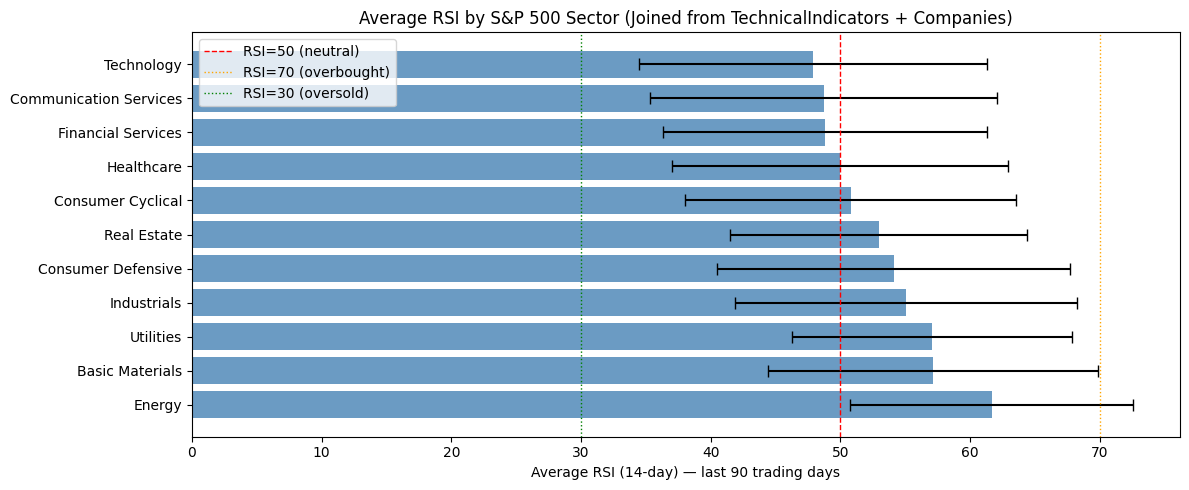


Pipeline check complete — database is queryable and analytically useful.


In [5]:
import matplotlib.pyplot as plt

query = """
    SELECT c.sector, AVG(ti.rsi_14) AS avg_rsi, STDDEV(ti.rsi_14) AS std_rsi,
           COUNT(*) AS n_obs
    FROM TechnicalIndicators ti
    JOIN Companies c ON ti.symbol = c.symbol
    WHERE ti.rsi_14 IS NOT NULL
      AND ti.date >= CURRENT_DATE - INTERVAL 90 DAY
      AND c.sector IS NOT NULL
    GROUP BY c.sector
    ORDER BY avg_rsi DESC
"""
rsi_by_sector = con.execute(query).df()
display(rsi_by_sector)

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(rsi_by_sector['sector'], rsi_by_sector['avg_rsi'],
        xerr=rsi_by_sector['std_rsi'], capsize=4, color='steelblue', alpha=0.8)
ax.axvline(50, color='red', linestyle='--', linewidth=1, label='RSI=50 (neutral)')
ax.axvline(70, color='orange', linestyle=':', linewidth=1, label='RSI=70 (overbought)')
ax.axvline(30, color='green', linestyle=':', linewidth=1, label='RSI=30 (oversold)')
ax.set_xlabel('Average RSI (14-day) — last 90 trading days')
ax.set_title('Average RSI by S&P 500 Sector (Joined from TechnicalIndicators + Companies)')
ax.legend()
plt.tight_layout()
plt.show()

print('\nPipeline check complete — database is queryable and analytically useful.')